In [3]:
import torch
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()

In [4]:

X = housing['data']
y = housing['target']

from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

(11610, 8) (5160, 8) (3870, 8)


In [5]:

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

Epoch: 1/20, loss: 0.9874402985346219, train_metric: 0.685, valid_metric: 0.554, 
Epoch: 2/20, loss: 0.5192880500364566, train_metric: 0.529, valid_metric: 0.506, 
Epoch: 3/20, loss: 0.4719829973931483, train_metric: 0.499, valid_metric: 0.501, 
Epoch: 4/20, loss: 0.45122451957099696, train_metric: 0.486, valid_metric: 0.476, 
Epoch: 5/20, loss: 0.44000451071777946, train_metric: 0.479, valid_metric: 0.5, 
Epoch: 6/20, loss: 0.4308904591465456, train_metric: 0.473, valid_metric: 0.464, 
Epoch: 7/20, loss: 0.4244167447172249, train_metric: 0.469, valid_metric: 0.464, 
Epoch: 8/20, loss: 0.41767381915704604, train_metric: 0.464, valid_metric: 0.454, 
Epoch: 9/20, loss: 0.4114030625866136, train_metric: 0.46, valid_metric: 0.451, 
Epoch: 10/20, loss: 0.40609060486486137, train_metric: 0.456, valid_metric: 0.497, 
Epoch: 11/20, loss: 0.40350739830289006, train_metric: 0.456, valid_metric: 0.458, 
Epoch: 12/20, loss: 0.3992853936002931, train_metric: 0.452, valid_metric: 0.443, 
Epoch: 13/2

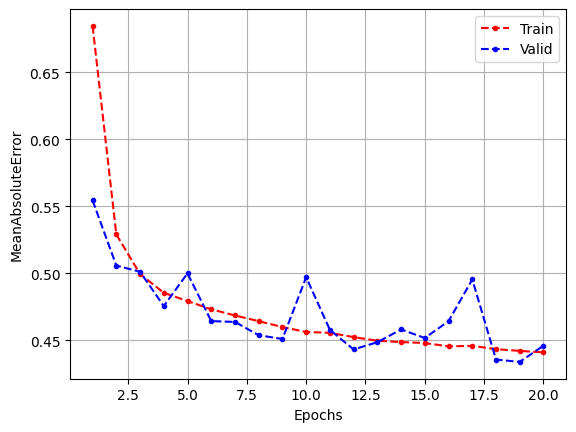

In [7]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

learning_rate = 0.1
n_epochs=20
device = 'cpu' # 'cuda'

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.Sigmoid(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)
class Model1(nn.Module):
	def __init__(self, n_features=8):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=30), 
			nn.Sigmoid(),
			nn.Linear(in_features=30, out_features=50), 
			nn.Sigmoid(),
			nn.Linear(in_features=50, out_features=1)
		)
        
	def forward(self, X):
		y = self.stack(X)
		return y
model = Model1().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = {
	'loss' : [],
	'train_metric' : [],
	'valid_metric' : [],
}
for epoch in range(n_epochs):
	# Training 
	total_loss = 0
	metric.reset()
	for X_batch, y_batch in train_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		model.train()
		y_pred = model(X_batch)
		loss = criterion(y_pred, y_batch)
		total_loss += loss.item()
		loss.backward()
		optimizer.step()
		optimizer.zero_grad()
		metric.update(y_pred, y_batch)
	
	avg_loss = total_loss / len(train_loader)
	history['loss'].append(avg_loss)

	avg_metric_train = metric.compute().item()
	history['train_metric'].append(avg_metric_train)

	# Evaluation 
	model.eval()
	metric.reset()
	for X_batch, y_batch in valid_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		with torch.no_grad():
			y_pred = model(X_batch)
			metric.update(y_pred, y_batch)

	avg_metric_valid = metric.compute().item()
	history['valid_metric'].append(avg_metric_valid)

	print(f'Epoch: {epoch+1}/{n_epochs}, loss: {avg_loss}, train_metric: {round(avg_metric_train,3)}, valid_metric: {round(avg_metric_valid,3)}, ')

	# if epoch>=2:
	# 	break

plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
plt.legend()
plt.grid()
plt.xlabel('Epochs')
plt.ylabel(f'{metric.__class__.__name__}')
plt.show()